In [20]:
!pip install tldextract requests beautifulsoup4 joblib
!pip install python-whois

In [40]:
import pandas as pd
import re, tldextract, requests, socket, whois
import urllib.parse
import numpy as np
from collections import Counter
from math import log2

import seaborn as sns
import matplotlib.pyplot as plt


from bs4 import BeautifulSoup
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from joblib import dump, load

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks
from tensorflow.keras.models import Sequential



In [22]:
all_tog = pd.read_csv('/content/malicious_phish.csv')  # Replace with your actual file path
#print(df)
all_tog = all_tog.dropna(subset=['url']).reset_index(drop=True)
all_tog['label'] = all_tog['type'].apply(lambda x: 0 if x.lower() == 'benign' else 1)

print(all_tog)


                                                      url        type  label
0                                        br-icloud.com.br    phishing      1
1                     mp3raid.com/music/krizz_kaliko.html      benign      0
2                         bopsecrets.org/rexroth/cr/1.htm      benign      0
3       http://www.garage-pirenne.be/index.php?option=...  defacement      1
4       http://adventure-nicaragua.net/index.php?optio...  defacement      1
...                                                   ...         ...    ...
651186            xbox360.ign.com/objects/850/850402.html    phishing      1
651187       games.teamxbox.com/xbox-360/1860/Dead-Space/    phishing      1
651188         www.gamespot.com/xbox360/action/deadspace/    phishing      1
651189      en.wikipedia.org/wiki/Dead_Space_(video_game)    phishing      1
651190          www.angelfire.com/goth/devilmaycrytonite/    phishing      1

[651191 rows x 3 columns]


In [23]:
vowels = "aeiou"
special_chars = r"!@#$%^&*()_+-=[]{};:',.<>?/\\|`~"
delimiters = r'[\-._~:/?#\[\]@!$&\'()*+,;=]'


In [24]:

# Helper Functions
def get_entropy(string):
    if not string:
        return 0
    counter = Counter(string)
    total = len(string)
    return -sum((count / total) * log2(count / total) for count in counter.values())

def count_vowels(s):
    return len(re.findall(r'[aeiouAEIOU]', s))

def count_consonants(s):
    return len(re.findall(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]', s))

def is_ip_address(domain):
    return 1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', domain) else 0

# Main feature extraction function
def extract_features(url):
    parsed = urllib.parse.urlparse(url)
    ext = tldextract.extract(url)

    domain = parsed.netloc or ext.domain + '.' + ext.suffix
    subdomain = ext.subdomain
    path = parsed.path
    query = parsed.query
    filename = path.split('/')[-1]
    file_ext = filename.split('.')[-1] if '.' in filename else ''

    domain_tokens = re.split(r'\W+', domain)
    path_tokens = re.split(r'\W+', path)

    features = {}

    # Binary features
    features['having_IP_Address'] = is_ip_address(domain)
    features['URL_Length'] = len(url)
    features['Shortining_Service'] = 1 if re.search(r'(bit\.ly|goo\.gl|tinyurl\.com|t\.co)', url) else 0
    features['having_At_Symbol'] = 1 if '@' in url else 0
    features['double_slash_redirecting'] = 1 if url.count('//') > 1 else 0
    features['Prefix_Suffix'] = 1 if '-' in ext.domain else 0
    features['having_Sub_Domain'] = 1 if subdomain else 0
    features['SSLfinal_State'] = 1 if parsed.scheme == 'https' else 0
    features['Domain_registeration_length'] = 1  # Placeholder

    # Other binary
    features['Favicon'] = 0  # Placeholder
    features['port'] = 1 if ':' in domain else 0
    features['HTTPS_token'] = 1 if 'https' in domain else 0
    features['Request_URL'] = 1 if len(path) else 0
    features['executable'] = 1 if '.exe' in url else 0
    features['isPortEighty'] = 1 if ':80' in domain else 0
    features['ISIpAddressInDomainName'] = 1 if is_ip_address(domain) else 0

    # Token-based features
    features['querylength'] = len(query)
    features['domain_token_count'] = len(domain_tokens)
    features['path_token_count'] = len(path_tokens)
    features['avgdomaintokenlen'] = np.mean([len(t) for t in domain_tokens]) if domain_tokens else 0
    features['longdomaintokenlen'] = max([len(t) for t in domain_tokens]) if domain_tokens else 0
    features['avgpathtokenlen'] = np.mean([len(t) for t in path_tokens]) if path_tokens else 0

    # Character composition
    features['charcompvowels'] = count_vowels(url)
    features['charcompace'] = url.count('%20')
    features['URL_DigitCount'] = sum(c.isdigit() for c in url)
    features['host_DigitCount'] = sum(c.isdigit() for c in domain)
    features['Directory_DigitCount'] = sum(c.isdigit() for c in path)
    features['File_name_DigitCount'] = sum(c.isdigit() for c in filename)
    features['Extension_DigitCount'] = sum(c.isdigit() for c in file_ext)
    features['Query_DigitCount'] = sum(c.isdigit() for c in query)

    features['URL_Letter_Count'] = sum(c.isalpha() for c in url)
    features['host_letter_count'] = sum(c.isalpha() for c in domain)
    features['Directory_LetterCount'] = sum(c.isalpha() for c in path)
    features['Filename_LetterCount'] = sum(c.isalpha() for c in filename)
    features['Extension_LetterCount'] = sum(c.isalpha() for c in file_ext)
    features['Query_LetterCount'] = sum(c.isalpha() for c in query)

    # Length based
    features['ldl_url'] = len(url)
    features['domainlength'] = len(domain)
    features['pathLength'] = len(path)
    features['subDirLen'] = len('/'.join(path.split('/')[:-1]))
    features['fileNameLen'] = len(filename)
    features['ArgLen'] = len(query)
    features['LongestVariableValue'] = max([len(p) for p in query.split('&')]) if query else 0
    features['LongestPathTokenLength'] = max([len(p) for p in path_tokens]) if path_tokens else 0
    features['Domain_LongestWordLength'] = max([len(p) for p in domain_tokens]) if domain_tokens else 0
    features['Path_LongestWordLength'] = max([len(p) for p in path_tokens]) if path_tokens else 0
    features['sub-Directory_LongestWordLength'] = max([len(p) for p in path.split('/')[:-1]]) if '/' in path else 0
    features['Arguments_LongestWordLength'] = max([len(p) for p in query.split('&')]) if query else 0

    # Ratios
    features['pathurlRatio'] = len(path)/len(url) if len(url) else 0
    features['ArgUrlRatio'] = len(query)/len(url) if len(url) else 0
    features['argDomanRatio'] = len(query)/len(domain) if len(domain) else 0
    features['domainUrlRatio'] = len(domain)/len(url) if len(url) else 0
    features['pathDomainRatio'] = len(path)/len(domain) if len(domain) else 0
    features['argPathRatio'] = len(query)/len(path) if len(path) else 0

    # Number rate
    features['NumberRate_URL'] = features['URL_DigitCount']/len(url) if len(url) else 0
    features['NumberRate_Domain'] = features['host_DigitCount']/len(domain) if len(domain) else 0
    features['NumberRate_DirectoryName'] = features['Directory_DigitCount']/len(path) if len(path) else 0
    features['NumberRate_FileName'] = features['File_name_DigitCount']/len(filename) if len(filename) else 0
    features['NumberRate_Extension'] = features['Extension_DigitCount']/len(file_ext) if file_ext else 0
    features['NumberRate_AfterPath'] = features['Query_DigitCount']/len(query) if len(query) else 0

    # Symbol count
    features['SymbolCount_URL'] = len(re.findall(r'\W', url))
    features['SymbolCount_Domain'] = len(re.findall(r'\W', domain))
    features['SymbolCount_Directoryname'] = len(re.findall(r'\W', path))
    features['SymbolCount_FileName'] = len(re.findall(r'\W', filename))
    features['SymbolCount_Extension'] = len(re.findall(r'\W', file_ext))
    features['SymbolCount_Afterpath'] = len(re.findall(r'\W', query))

    # Entropy
    features['entropy_url'] = get_entropy(url)
    features['entropy_domain'] = get_entropy(domain)
    features['entropy_path'] = get_entropy(path)
    features['entropy_file'] = get_entropy(filename)
    features['entropy_ext'] = get_entropy(file_ext)
    features['entropy_after_path'] = get_entropy(query)

    # Extra content placeholder
    features['URL_sensitiveWord'] = int(any(word in url.lower() for word in ['secure', 'account', 'webscr', 'login', 'ebayisapi', 'banking']))
    features['URLQueries_variable'] = query.count('=')
    features['spcharUrl'] = len(re.findall(r'[^\w]', url))
    features['delimeter_Domain'] = domain.count('.')
    features['delimeter_path'] = path.count('/')
    features['delimeter_Count'] = url.count('/') + url.count('.') + url.count('-') + url.count('?')

    return features


In [25]:
# Extract features for each URL
feature_df = pd.DataFrame([extract_features(url) for url in all_tog['url'].tolist()])

# Concatenate the features with all original columns from all_tog
full_df = pd.concat([all_tog.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

# Save full DataFrame with both metadata and extracted features
full_df.to_csv('list_urls_copy.csv', index=False)

print(f"✅ Saved {full_df.shape[0]} URLs with {full_df.shape[1]} total columns to list_urls_copy.csv")


✅ Saved 651191 URLs with 81 total columns to list_urls_copy.csv


In [26]:
new_list= pd.read_csv('/content/list_urls_copy.csv')
display(new_list)


,url,type,label,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,...,entropy_path,entropy_file,entropy_ext,entropy_after_path,URL_sensitiveWord,URLQueries_variable,spcharUrl,delimeter_Domain,delimeter_path,delimeter_Count
0,br-icloud.com.br,phishing,1,0,16,0,0,0,1,0,...,3.375000,3.375000,1.000000,0.000000,0,0,3,2,0,3
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,35,0,0,0,0,0,...,4.079143,3.454822,2.000000,0.000000,0,0,4,1,2,4
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,31,0,0,0,0,0,...,3.708093,2.321928,1.584963,0.000000,0,0,5,1,3,5
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,0,88,0,0,0,1,1,...,3.121928,2.947703,0.918296,4.280341,0,4,16,2,1,8
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,0,235,0,0,0,1,0,...,3.121928,2.947703,0.918296,5.360074,0,3,13,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651186,xbox360.ign.com/objects/850/850402.html,phishing,1,0,39,0,0,0,0,1,...,4.355539,3.277613,2.000000,0.000000,0,0,6,1,3,6
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing,1,0,44,0,0,0,0,1,...,4.243300,0.000000,0.000000,0.000000,0,0,8,1,4,8
651188,www.gamespot.com/xbox360/action/deadspace/,phishing,1,0,42,1,0,0,0,1,...,4.147921,0.000000,0.000000,0.000000,0,0,6,1,4,6
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing,1,0,45,0,0,0,0,1,...,4.102313,3.675311,0.000000,0.000000,0,0,6,1,2,4


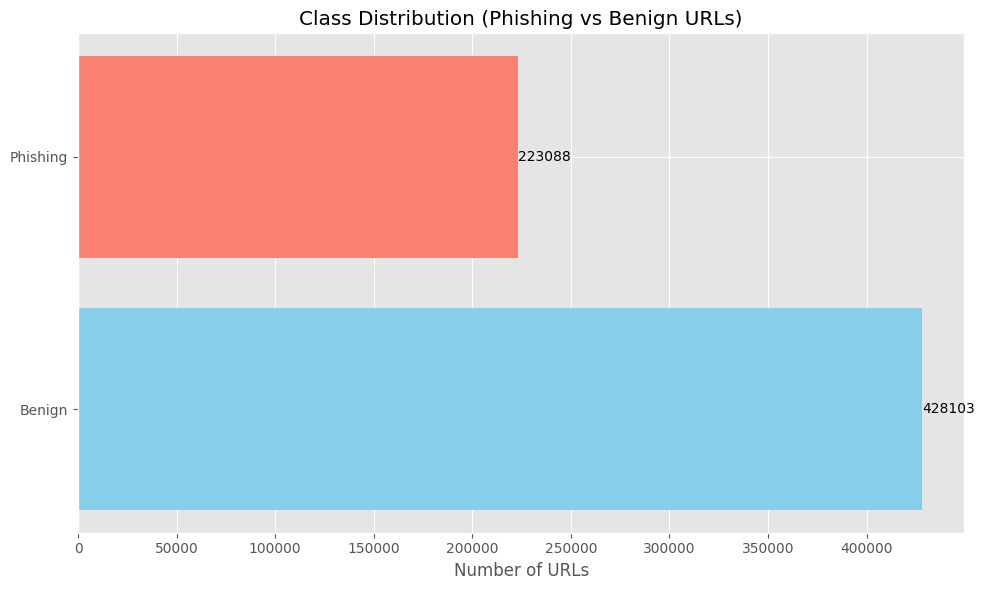


Summary Statistics:
                             count       mean        std  min   25%   50%  \
having_IP_Address         651191.0   0.011035   0.104467  0.0   0.0   0.0   
URL_Length                651191.0  60.156831  44.753902  1.0  32.0  47.0   
Shortining_Service        651191.0   0.053728   0.225480  0.0   0.0   0.0   
having_At_Symbol          651191.0   0.002067   0.045417  0.0   0.0   0.0   
double_slash_redirecting  651191.0   0.002357   0.048494  0.0   0.0   0.0   
...                            ...        ...        ...  ...   ...   ...   
URLQueries_variable       651191.0   0.593509   1.510407  0.0   0.0   0.0   
spcharUrl                 651191.0   8.959292   7.790773  0.0   4.0   7.0   
delimeter_Domain          651191.0   1.258708   0.627735  1.0   1.0   1.0   
delimeter_path            651191.0   2.317042   1.566924  0.0   1.0   2.0   
delimeter_Count           651191.0   6.919921   4.327135  0.0   4.0   6.0   

                           75%     max  
having_IP_Add

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks

# Sanity check
if 'label' not in new_list.columns:
    # Dummy guess based on URL length
    new_list['label'] = new_list['URL_Length'].apply(lambda x: 1 if x > 75 else 0)

# Class Distribution Data
class_dist = new_list['label'].value_counts().reset_index()
class_dist.columns = ['Class', 'Num_Observations']
class_dist['Class'] = class_dist['Class'].map({0: 'Benign', 1: 'Phishing'})

 # Plot Class Distribution
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'salmon']
plt.barh(class_dist['Class'], class_dist['Num_Observations'], color=colors)
plt.xlabel("Number of URLs")
plt.title("Class Distribution (Phishing vs Benign URLs)")
for index, value in enumerate(class_dist['Num_Observations']):
    plt.text(value, index, str(value), va='center')
plt.tight_layout()
plt.show()





# Feature Matrix and Labels
X = new_list.drop(columns=['url', 'label'])  # drop 'Url' and keep only features
y = new_list['label']

# Summary Statistics & Data Info
print("\nSummary Statistics:")
print(X.describe().T)

print("\nDataset Info:")
X.info()

# Data Splitting (Train-Test-Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.33, random_state=1)

# Early Stopping Callback for Neural Networks
es_cb = callbacks.EarlyStopping(monitor='loss', min_delta=0.001, patience=5, restore_best_weights=True)


In [28]:
print(new_list)

                                                      url        type  label  \
0                                        br-icloud.com.br    phishing      1   
1                     mp3raid.com/music/krizz_kaliko.html      benign      0   
2                         bopsecrets.org/rexroth/cr/1.htm      benign      0   
3       http://www.garage-pirenne.be/index.php?option=...  defacement      1   
4       http://adventure-nicaragua.net/index.php?optio...  defacement      1   
...                                                   ...         ...    ...   
651186            xbox360.ign.com/objects/850/850402.html    phishing      1   
651187       games.teamxbox.com/xbox-360/1860/Dead-Space/    phishing      1   
651188         www.gamespot.com/xbox360/action/deadspace/    phishing      1   
651189      en.wikipedia.org/wiki/Dead_Space_(video_game)    phishing      1   
651190          www.angelfire.com/goth/devilmaycrytonite/    phishing      1   

        having_IP_Address  URL_Length  

In [29]:
to_remove = ['url', 'type']

X = new_list.drop(columns=to_remove, errors='ignore')
X_numeric = X.select_dtypes(include=[np.number])
y = new_list['label']

Imputed feature shape: (651191, 79)


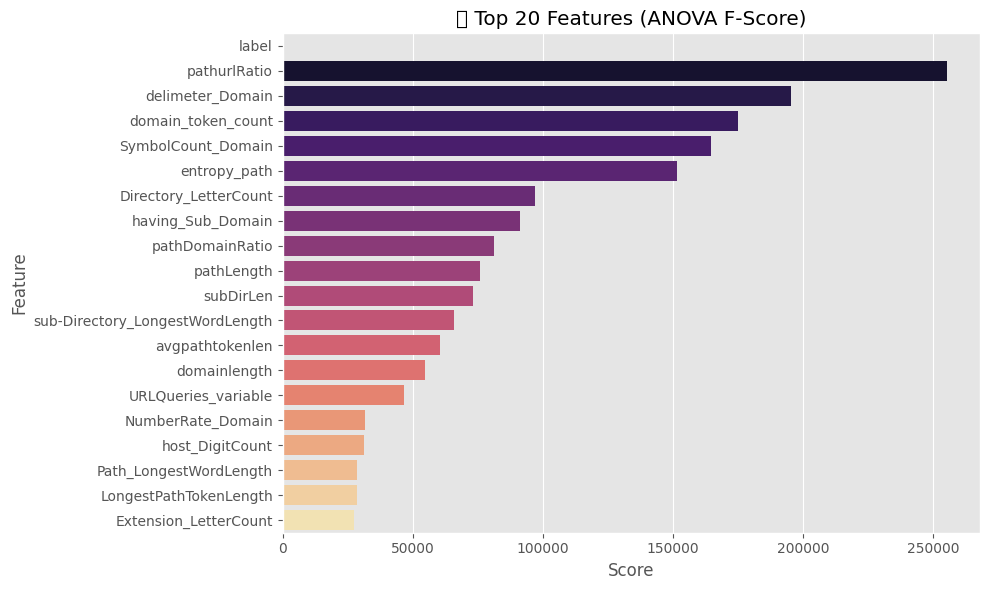

In [30]:
from sklearn.impute import SimpleImputer

# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric)

# Check shape
print("Imputed feature shape:", X_imputed.shape)

# Select top 20 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X_imputed, y)

# Get scores and feature names
scores = selector.scores_
features = X_numeric.columns
score_df = pd.DataFrame({'Feature': features, 'Score': scores})
top_features = score_df.sort_values(by='Score', ascending=False).head(20)

# Plot the top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Feature', data=top_features, palette='magma')
plt.title("🔥 Top 20 Features (ANOVA F-Score)")
plt.tight_layout()
plt.show()


In [31]:



#@title train /test

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Standardize features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Store model predictions
# results = {}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train, validation, test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Early stopping for Keras
es_cb = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Track results
results = {}
history_dict = {}

In [33]:
#@title random forest model

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
results['RandomForest'] = acc_rf

print("🎯 Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

# Save prediction as label_static
new_list['label_static'] = rf.predict(X_scaled)
label_static_acc = accuracy_score(new_list['label'], new_list['label_static'])
print(f"✅ Accuracy of label_static (Random Forest): {label_static_acc:.4f}")

🎯 Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    141516
           1       1.00      1.00      1.00     73378

    accuracy                           1.00    214894
   macro avg       1.00      1.00      1.00    214894
weighted avg       1.00      1.00      1.00    214894

✅ Accuracy of label_static (Random Forest): 1.0000


In [41]:
#@title train model mlp with sgd, adam, rmsprop
def build_and_train_model(name, optimizer, X_train, y_train, X_val, y_val):
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    print(f"📦 Training {name} model...")
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=5,
                        batch_size=32,
                        callbacks=[es_cb],
                        verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"🎯 {name} Test Accuracy: {acc:.4f}")
    results[name] = acc
    history_dict[name] = history
    return model

# Train models with different optimizers
model_rmsprop = build_and_train_model("RMSprop", optimizers.RMSprop(), X_train, y_train, X_val, y_val)
model_sgd     = build_and_train_model("SGD", optimizers.SGD(), X_train, y_train, X_val, y_val)
model_adam    = build_and_train_model("Adam", optimizers.Adam(), X_train, y_train, X_val, y_val)


📦 Training RMSprop model...
🎯 RMSprop Test Accuracy: 1.0000
📦 Training SGD model...
🎯 SGD Test Accuracy: 1.0000
📦 Training Adam model...
🎯 Adam Test Accuracy: 1.0000


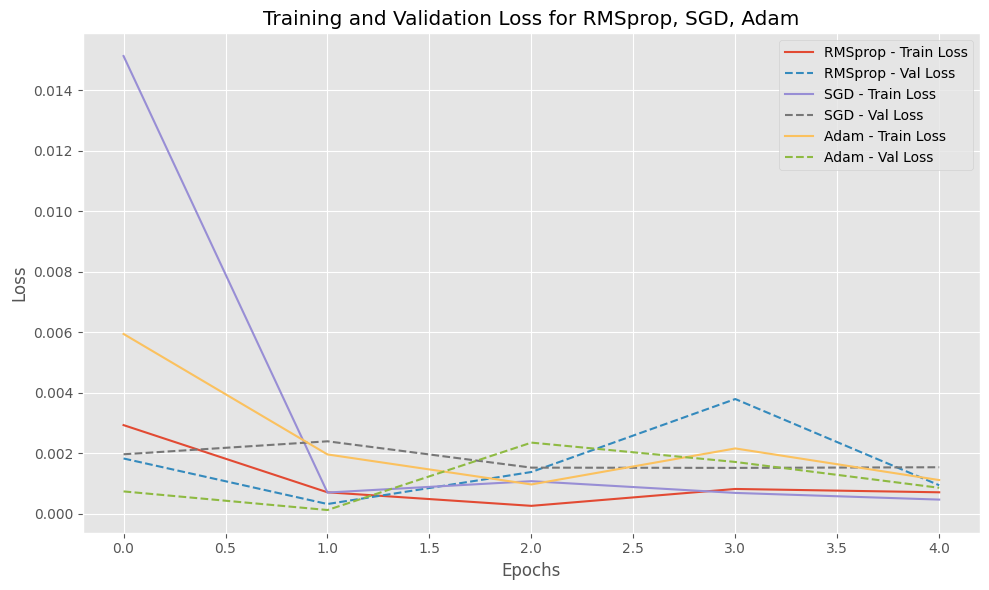

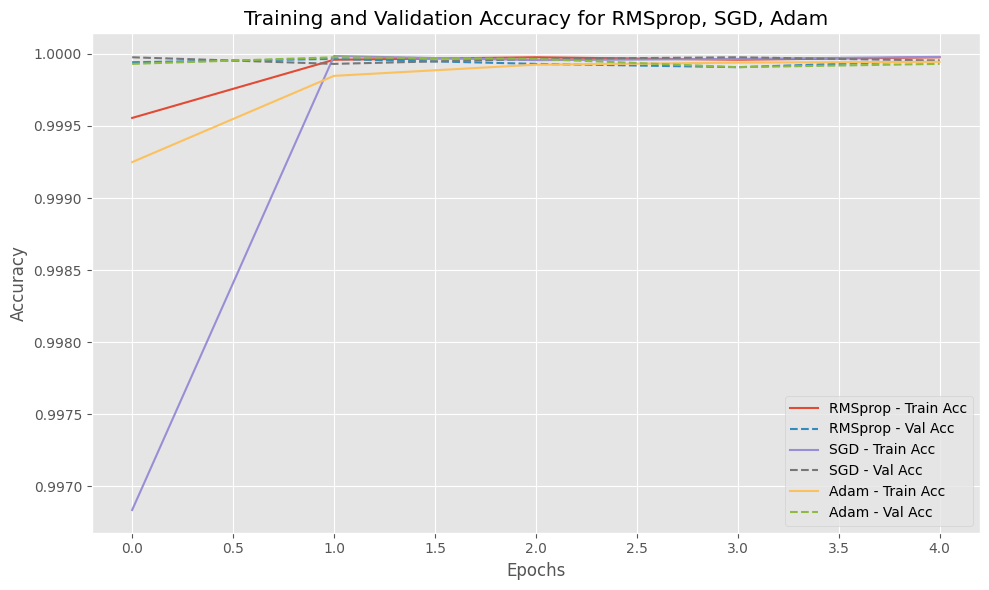

In [42]:
# ===========================
# 📈 LOSS Curves for All Optimizers
# ===========================
plt.figure(figsize=(10, 6))
for name, history in history_dict.items():
    plt.plot(history.history['loss'], label=f'{name} - Train Loss')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{name} - Val Loss')

plt.title('Training and Validation Loss for RMSprop, SGD, Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===========================
# 📈 ACCURACY Curves for All Optimizers
# ===========================
plt.figure(figsize=(10, 6))
for name, history in history_dict.items():
    plt.plot(history.history['accuracy'], label=f'{name} - Train Acc')
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{name} - Val Acc')

plt.title('Training and Validation Accuracy for RMSprop, SGD, Adam')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
display(new_list)

,url,type,label,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,...,entropy_file,entropy_ext,entropy_after_path,URL_sensitiveWord,URLQueries_variable,spcharUrl,delimeter_Domain,delimeter_path,delimeter_Count,label_static
0,br-icloud.com.br,phishing,1,0,16,0,0,0,1,0,...,3.375000,1.000000,0.000000,0,0,3,2,0,3,1
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,35,0,0,0,0,0,...,3.454822,2.000000,0.000000,0,0,4,1,2,4,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,31,0,0,0,0,0,...,2.321928,1.584963,0.000000,0,0,5,1,3,5,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,0,88,0,0,0,1,1,...,2.947703,0.918296,4.280341,0,4,16,2,1,8,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,0,235,0,0,0,1,0,...,2.947703,0.918296,5.360074,0,3,13,1,1,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651186,xbox360.ign.com/objects/850/850402.html,phishing,1,0,39,0,0,0,0,1,...,3.277613,2.000000,0.000000,0,0,6,1,3,6,1
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing,1,0,44,0,0,0,0,1,...,0.000000,0.000000,0.000000,0,0,8,1,4,8,1
651188,www.gamespot.com/xbox360/action/deadspace/,phishing,1,0,42,1,0,0,0,1,...,0.000000,0.000000,0.000000,0,0,6,1,4,6,1
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing,1,0,45,0,0,0,0,1,...,3.675311,0.000000,0.000000,0,0,6,1,2,4,1


In [45]:
selector = SelectKBest(score_func=f_classif, k=20)
X_selected_array = selector.fit_transform(X_numeric, y)

selected_ft_idx = selector.get_support(indices=True)
sel_fts = X_numeric.columns[selected_ft_idx].tolist()

# Remove any of the banned columns if present
sel_fts = [f for f in sel_fts if f not in to_remove]

# Final dataset for training
sel = new_list[sel_fts + ['label']]
X = sel.drop('label', axis=1)
y = sel['label']

In [54]:
best_model_name = max(results, key=results.get)
best_model = results[best_model_name]
print(f"🏆 Best model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

# Step 5: Save best model
if best_model_name == "RandomForest":
    joblib.dump(best_model, "phishing_model_copy.pkl")
    files.download("phishing_model_copy.pkl")
else:
    best_model.save("phishing_detector_model.h5")
    files.download("phishing_detector_model.h5")

# Save scaler
joblib.dump(scaler, "scaler.pkl")
files.download("scaler.pkl")


🏆 Best model: RandomForest with accuracy 1.0000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:

# Save selected features
sel.to_csv("selected_features_copy.csv", index=False)
files.download("selected_features_copy.csv")
sel.columns

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Index(['label', 'having_Sub_Domain', 'domain_token_count', 'avgpathtokenlen',
       'host_DigitCount', 'Directory_LetterCount', 'Extension_LetterCount',
       'domainlength', 'pathLength', 'subDirLen', 'LongestPathTokenLength',
       'Path_LongestWordLength', 'sub-Directory_LongestWordLength',
       'pathurlRatio', 'pathDomainRatio', 'NumberRate_Domain',
       'SymbolCount_Domain', 'entropy_path', 'URLQueries_variable',
       'delimeter_Domain', 'label'],
      dtype='object')